# RetroScope REST API demo

This notebook shows the basic workflow with the RetroScope REST API:

1. List gallery captures.
2. Pick the first single-image capture (type == "snapshot").
3. Download that capture.
4. Convert it to grayscale with OpenCV.

RetroScope app needs to run first. By default the API is available on port `8765`.

In [15]:
from io import BytesIO
from pathlib import Path

import cv2
import httpx
import numpy as np
from IPython.display import display
from PIL import Image

# Use http://<ip-of-pi>:8765 when calling the API from another machine.
API_BASE = "http://127.0.0.1:8765"
client = httpx.Client(base_url=API_BASE, timeout=30.0)

## List all captures

In [16]:
response = client.get("/api/v1/captures", params={"type": "all", "limit": 500})
response.raise_for_status()

payload = response.json()
captures = payload["captures"]

print(f"Total captures by API: {payload['total']}")
print(f"Captures loaded: {len(captures)}")

# Print a overview of the first few captures.
for item in captures[:10]:
    print(
        item["id"][:12],
        item["type"],
        item["filename"],
        item["captured_at"],
        f"{item['width']}x{item['height']}",
    )

Total captures by API: 107
Captures loaded: 107
7149abd4380a video 20260606_141239_20x_video.mp4 2026-06-06T14:12:39 1280x720
3683ddceb51a video 20260606_140708_20x_video.mp4 2026-06-06T14:07:08 1280x720
687ed3a04097 video 20260606_140520_20x_video.mp4 2026-06-06T14:05:20 1280x720
0b18abbb976d stack 20260606_140512_20x_stack.ome.tiff 2026-06-06T14:05:12 1280x720
880b651f690d stack 20260606_140455_20x_stack.ome.tiff 2026-06-06T14:04:55 1280x720
523f6d713528 snapshot 20260606_140419_20x_capture.ome.tiff 2026-06-06T14:04:19 1280x720
d3895527de73 stitch 20260606_140335_4x_scan.ome.tiff 2026-06-06T14:03:35 3362x1904
4299abcc01ae stitch 20260606_140301_4x_scan.ome.tiff 2026-06-06T14:03:01 3840x2160
4bca78e27f10 snapshot 20260606_140227_4x_capture.ome.tiff 2026-06-06T14:02:27 1280x720
4cfec7d96d77 video 20260606_140217_4x_video.mp4 2026-06-06T14:02:17 1280x720


## Select the first single-image capture

The API uses the type `snapshot` for single-image captures.

In [17]:
single_images = [item for item in captures if item["type"] == "snapshot"]

if not single_images:
    raise RuntimeError("No snapshot captures found in the gallery.")

capture = single_images[0]
capture

{'id': '523f6d713528baa2d9d9c9186f4cb7eb4218b2d660dfff3edd0250df65a4edeb',
 'filename': '20260606_140419_20x_capture.ome.tiff',
 'type': 'snapshot',
 'captured_at': '2026-06-06T14:04:19',
 'objective': '20x',
 'width': 1280,
 'height': 720,
 'file_size': 2766560,
 'format': 'OME-TIFF',
 'tags': [],
 'position': {'x': 2956, 'y': -7704, 'z': 18667},
 'metadata': {'version': 1,
  'type': 'snapshot',
  'captured_at': '2026-06-06T14:04:19',
  'objective': '20x',
  'position': {'x': 2956, 'y': -7704, 'z': 18667},
  'width': 1280,
  'height': 720,
  'resolution': {'width': 1280, 'height': 720},
  'format': 'OME-TIFF',
  'tags': [],
  'ifd_start': 0,
  'ifd_count': 1,
  'ome_series': [{'index': 0,
    'name': '20260606_140419_20x_capture.ome',
    'kind': 'snapshot',
    'width': 1280,
    'height': 720,
    'size_z': 1,
    'size_t': 1,
    'size_c': 3,
    'ifds': [0],
    'planes': [{'z': 0,
      't': 0,
      'c': 0,
      'position': {'x': None, 'y': None, 'z': None}}],
    'metadata': {

## Download and decode the capture

In [18]:
download_response = client.get(f"/api/v1/captures/{capture['id']}/download")
download_response.raise_for_status()

image_bytes = download_response.content
print(f"Downloaded {len(image_bytes):,} bytes from {capture['filename']}")

# Use the first plane of OME-TIFF.
pil_image = Image.open(BytesIO(image_bytes))
pil_image.seek(0)
rgb = np.asarray(pil_image.convert("RGB"))

print(f"Decoded RGB image shape: {rgb.shape}")

Downloaded 2,766,560 bytes from 20260606_140419_20x_capture.ome.tiff
Decoded RGB image shape: (720, 1280, 3)


## Convert to grayscale with OpenCV

In [19]:
gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

print(f"Grayscale image shape: {gray.shape}")
print(f"Pixel range: min={gray.min()}, max={gray.max()}")

Grayscale image shape: (720, 1280)
Pixel range: min=20, max=155


## Preview original and grayscale output

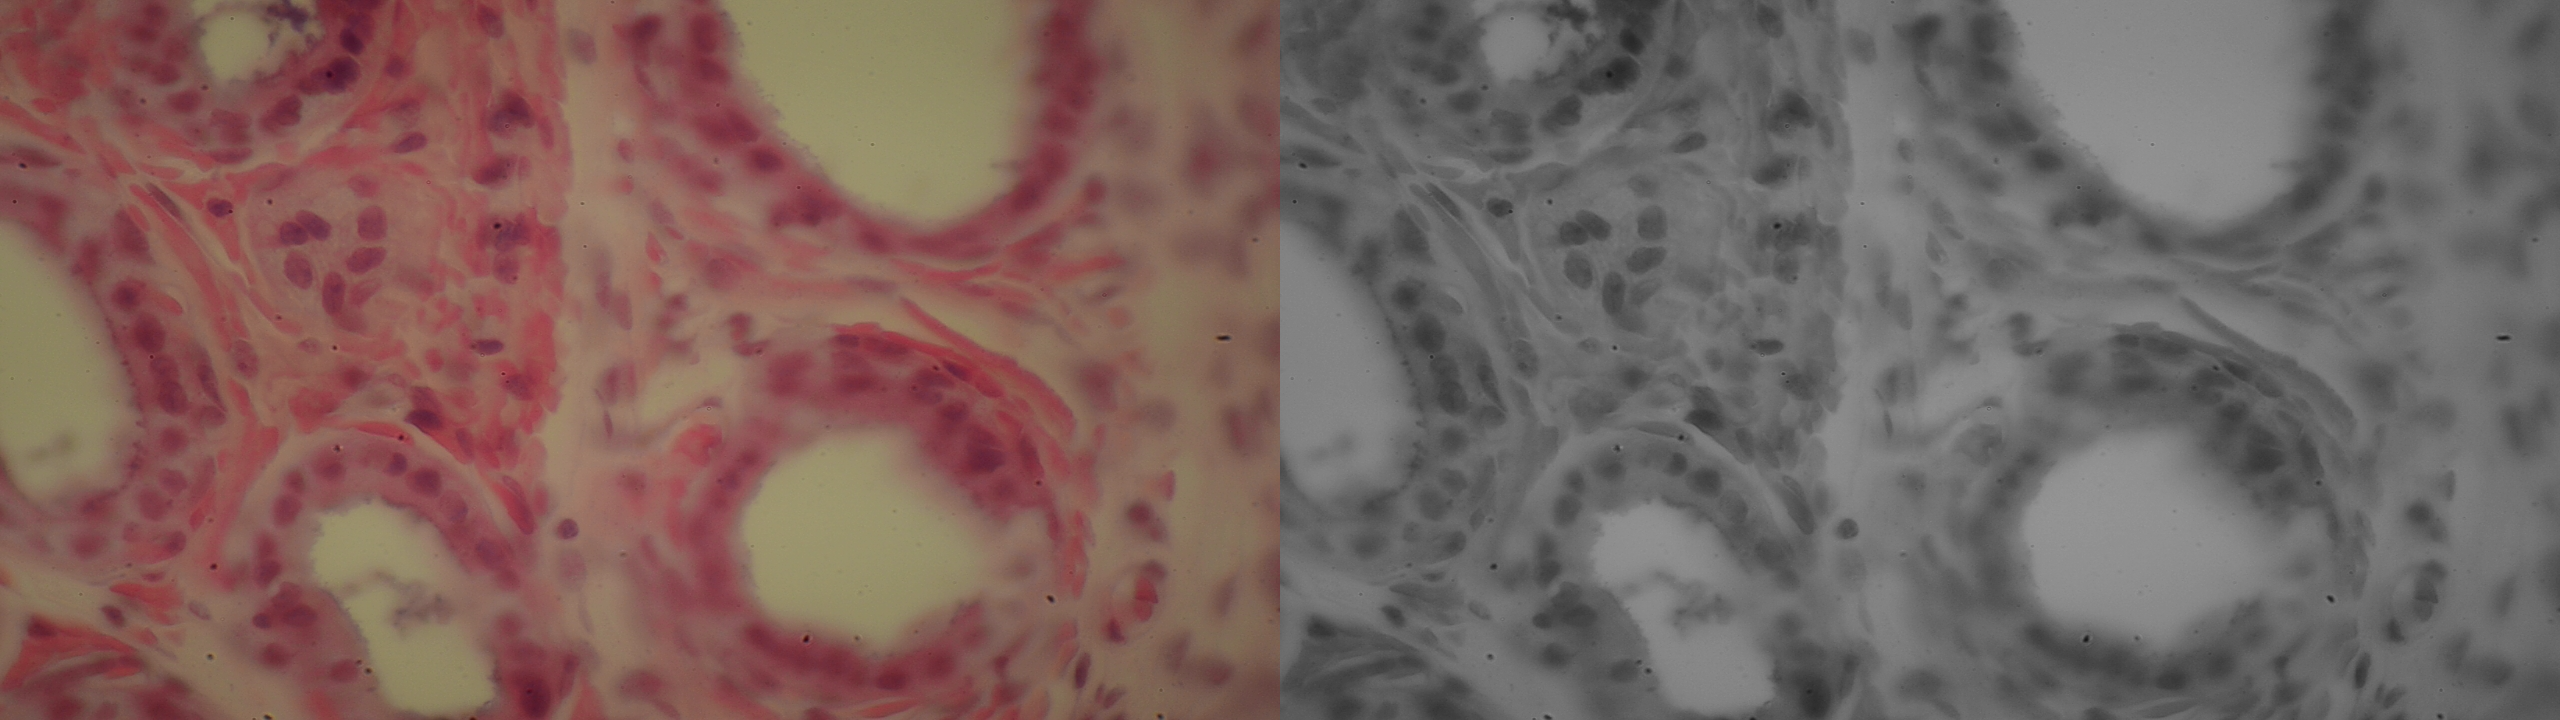

In [20]:
rgb_preview = Image.fromarray(rgb)
gray_preview = Image.fromarray(gray).convert("RGB")

preview = Image.new(
    "RGB",
    (rgb_preview.width + gray_preview.width, max(rgb_preview.height, gray_preview.height)),
    "white",
)
preview.paste(rgb_preview, (0, 0))
preview.paste(gray_preview, (rgb_preview.width, 0))

display(preview)